# Plot signal and idler gain

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import h5py
import inspect
from tqdm import tqdm
import sys
import math
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.constants import Planck

%matplotlib widget

# style
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['font.size'] = 15
plt.rcParams['legend.fontsize'] = 17
plt.rcParams['legend.frameon'] = False

In [57]:
# Load covariance pump sweep data

folder  = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-06/Covariance/'
file = sorted(
        (f for f in os.listdir(folder) if f.endswith('.hdf5')),
        key=lambda f: os.path.getmtime(os.path.join(folder, f))
    )[-1]

file = os.path.join(folder, file)

# file = r'/media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-04/Covariance/2026-04-14_15_05_45.hdf5'

with h5py.File(file, 'r') as dataset:
    run = list(dataset.keys())[0]
    amp_pump = np.sort(dataset['{}'.format(run)].attrs['amp_pump'])

    # load metadata
    idx_str = '{}/{}'.format(run, 0)
    attr_str = '{}'.format(run)

    df = dataset[attr_str].attrs['df']
    Npixels = dataset[attr_str].attrs['Npixels']
    freq_arr = np.asarray(dataset[idx_str]['freq comb'])
    n_modes = len(freq_arr)
    N_total = dataset[idx_str]['USB ON'].shape[0]

# Load metadata only

print('File:', file)
print('Pump amps:', amp_pump)
print('Frequency comb (GHz):', freq_arr/1e9)
print('Output modes: ' , n_modes)
print('Frequency spacing (dHz):', df)
print('Number of pixels:', Npixels)

File: /media/nanophys-meas/DR_BACKUP/Jai LKIPA Data/2026-06/Covariance/2026-06-05_05_03_30.hdf5
Pump amps: [0.  0.5 0.6 0.6 0.7]
Frequency comb (GHz): [4.4207 4.4208 4.4209 4.421  4.4211 4.4212 4.4213 4.4214 4.4215 4.4216
 4.4217 4.4218 4.4219 4.422  4.4221 4.4222 4.4223 4.4224 4.4225 4.4226
 4.4227 4.4228 4.4229 4.423  4.4231 4.4232 4.4233 4.4234 4.4235 4.4236
 4.4237 4.4238 4.4239 4.424  4.4241 4.4242 4.4243 4.4244 4.4245 4.4246
 4.4247 4.4248 4.4249 4.425  4.4251 4.4252 4.4253 4.4254 4.4255 4.4256
 4.4257 4.4258 4.4259 4.426  4.4261 4.4262 4.4263 4.4264 4.4265 4.4266
 4.4267 4.4268 4.4269 4.427  4.4271 4.4272 4.4273 4.4274 4.4275 4.4276
 4.4277 4.4278 4.4279 4.428  4.4281 4.4282 4.4283 4.4284 4.4285 4.4286
 4.4287 4.4288 4.4289 4.429  4.4291 4.4292 4.4293 4.4294 4.4295 4.4296
 4.4297 4.4298 4.4299 4.43   4.4301]
Output modes:  95
Frequency spacing (dHz): 100000.0
Number of pixels: 100000


In [58]:
# Collect x & p quadratures across all pixels and pump amplitudes
usb_list = np.zeros((len(amp_pump), Npixels,  n_modes), dtype=complex)

for pump_amp_idx in range(len(amp_pump)):
        print('Processing pump amplitude: ' + str(np.round(amp_pump[pump_amp_idx], 3)))

        idx_str = '{}/{}'.format(run, pump_amp_idx)

        with h5py.File(file, 'r') as dataset:
            usb_list[pump_amp_idx]  = dataset[idx_str]['USB ON'][:]
            print('data acquired')

x_list = np.real(usb_list)
p_list = np.imag(usb_list)

Processing pump amplitude: 0.0
data acquired
Processing pump amplitude: 0.5
data acquired
Processing pump amplitude: 0.6
data acquired
Processing pump amplitude: 0.6
data acquired
Processing pump amplitude: 0.7
data acquired


In [59]:
# Extract signal and idler gain for each pump

signal_gain = np.zeros((len(amp_pump), n_modes))
idler_gain = np.zeros_like(signal_gain)

for pump_amp_idx in range(len(amp_pump)):
    for mode_idx in range(n_modes):
        signal_gain[pump_amp_idx, mode_idx] = np.mean(x_list[pump_amp_idx, :, mode_idx]**2 + p_list[pump_amp_idx, :, mode_idx]**2)
        idler_gain[pump_amp_idx, mode_idx] = np.abs(np.mean(
            x_list[pump_amp_idx, :, mode_idx] * x_list[pump_amp_idx, :, -mode_idx-1] - p_list[pump_amp_idx, :, mode_idx] * p_list[pump_amp_idx, :, -mode_idx-1]
        ))

signal_gain_dB = 10 * np.log10(signal_gain / signal_gain[0])
idler_gain_dB = 10 * np.log10(idler_gain / signal_gain[0])

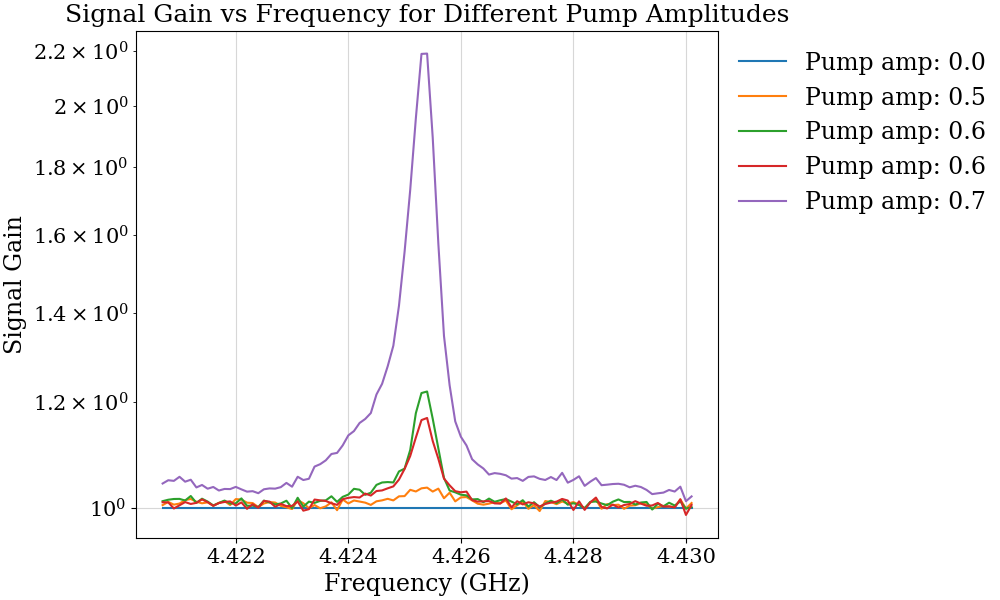

In [60]:
# Plot signal gain

fig_sig, ax_sig = plt.subplots(figsize=(10, 6))

for pump_amp_idx in range(len(amp_pump)):
    ax_sig.semilogy(freq_arr/1e9, signal_gain[pump_amp_idx]/signal_gain[0], label='Pump amp: {}'.format(np.round(amp_pump[pump_amp_idx], 3)))
ax_sig.set_xlabel('Frequency (GHz)')
ax_sig.set_ylabel('Signal Gain')
ax_sig.set_title('Signal Gain vs Frequency for Different Pump Amplitudes')
ax_sig.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax_sig.grid(alpha=0.5)
plt.show()

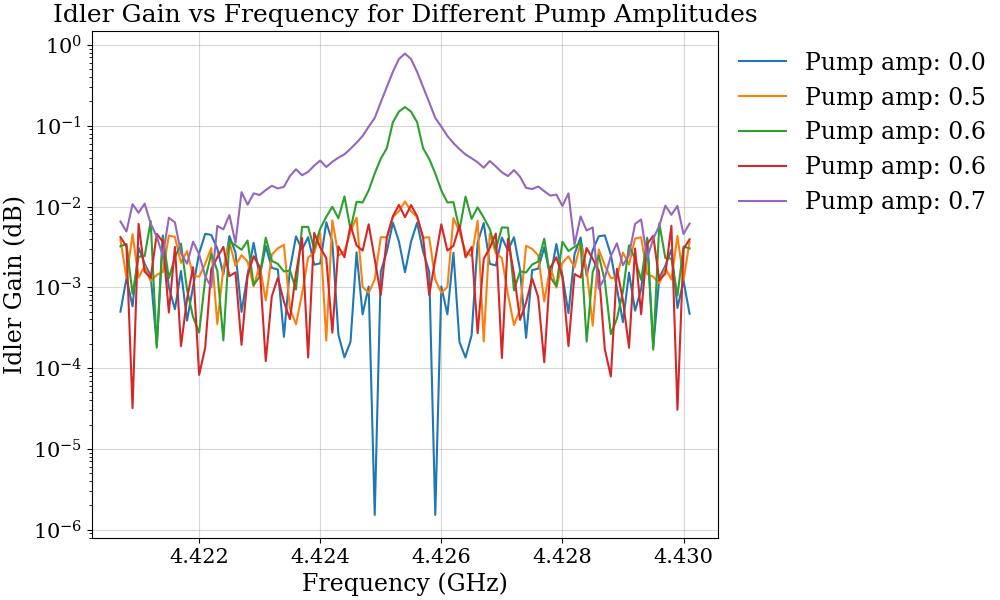

In [61]:
# Plot idler gain

fig_id, ax_id = plt.subplots(figsize=(10, 6))

for pump_amp_idx in range(len(amp_pump)):
    ax_id.semilogy(freq_arr/1e9, idler_gain[pump_amp_idx]/signal_gain[0], label='Pump amp: {}'.format(np.round(amp_pump[pump_amp_idx], 3)))

# plot settings
ax_id.set_xlabel('Frequency (GHz)')
ax_id.set_ylabel('Idler Gain (dB)')
ax_id.set_title('Idler Gain vs Frequency for Different Pump Amplitudes')
#ax_id.set_ylim([-20, 20])
ax_id.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax_id.grid(alpha=0.5)
plt.show()